# Statistical Mean Analysis & Oceanographic Visualization (Aruba vs. Oregon)
### SIDS-Apex Coastal Climatology comparative study

This notebook performs a detailed analysis of the mean state of all physical and biogeochemical variables across two contrasting marine ecosystems:
1. **Aruba (Tropical Carbonate Platform)**: Warm, saline, stable pH, driven by steady Caribbean currents.
2. **Oregon (Temperate Coastal Upwelling)**: Highly variable, seasonal upwelling bringing cold, nutrient-rich, low-pH waters to the surface.

We calculate and display overall means (with scientific interpretation of circular velocity statistics) and visualize them spatially and temporally.

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cmocean
import seaborn as sns

# Set style for premium scientific visualization
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15,
    'figure.dpi': 150
})

## 1. Load NetCDF Datasets
We load the netCDF datasets for Aruba and Oregon (both physical and biogeochemical).

In [2]:
aruba_bgc_path = "D:/antigravity/Coastcomparedfinalpaper/aruba_bgc.nc"
aruba_phy_path = "D:/antigravity/Coastcomparedfinalpaper/aruba_phy.nc"
oregon_bgc_path = "D:/antigravity/Coastcomparedfinalpaper/oregon_bgc2.nc"
oregon_phy_path = "D:/antigravity/Coastcomparedfinalpaper/oregon_phy2.nc"

print("Loading datasets...")
ds_a_bgc = xr.open_dataset(aruba_bgc_path)
ds_a_phy = xr.open_dataset(aruba_phy_path)
ds_o_bgc = xr.open_dataset(oregon_bgc_path)
ds_o_phy = xr.open_dataset(oregon_phy_path)

print("Aruba BGC dimensions & vars:", dict(ds_a_bgc.dims), list(ds_a_bgc.data_vars))
print("Aruba PHY dimensions & vars:", dict(ds_a_phy.dims), list(ds_a_phy.data_vars))
print("Oregon BGC dimensions & vars:", dict(ds_o_bgc.dims), list(ds_o_bgc.data_vars))
print("Oregon PHY dimensions & vars:", dict(ds_o_phy.dims), list(ds_o_phy.data_vars))

Loading datasets...


d:\antigravity\Coastcomparedfinalpaper\.venv\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
d:\antigravity\Coastcomparedfinalpaper\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Aruba BGC dimensions & vars: {'time': 1431, 'depth': 1, 'latitude': 1, 'longitude': 2} ['ph', 'dissic', 'talk']
Aruba PHY dimensions & vars: {'time': 34345, 'depth': 1, 'latitude': 5, 'longitude': 7} ['uo', 'vo', 'so', 'thetao', 'speed', 'direction']
Oregon BGC dimensions & vars: {'time': 1431, 'depth': 1, 'latitude': 3, 'longitude': 1} ['ph', 'dissic', 'talk']
Oregon PHY dimensions & vars: {'time': 34345, 'depth': 1, 'latitude': 10, 'longitude': 5} ['uo', 'vo', 'so', 'thetao', 'speed', 'direction']


C:\Users\chris\AppData\Local\Temp\ipykernel_32720\648392748.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Aruba BGC dimensions & vars:", dict(ds_a_bgc.dims), list(ds_a_bgc.data_vars))
C:\Users\chris\AppData\Local\Temp\ipykernel_32720\648392748.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Aruba PHY dimensions & vars:", dict(ds_a_phy.dims), list(ds_a_phy.data_vars))
C:\Users\chris\AppData\Local\Temp\ipykernel_32720\648392748.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more co

## 2. Statistical Mean Calculations
Here we calculate the overall mean values of all variables in each dataset.

### Velocity & Direction calculations
Ocean currents are vector quantities. Simple arithmetic averages of current direction (angles in degrees) can lead to serious errors due to circular wrap-around (e.g., mean of 1° and 359° is 180° arithmetically, but circular/vector mean is 0°). We calculate:
1. **Arithmetic Mean** of the raw pre-calculated variables.
2. **Circular Mean** of direction (averaging unit vectors of angles).
3. **True Vector Mean** (calculating direction and magnitude from the mean of velocity components `uo` and `vo`).

In [3]:
def get_dataset_means(ds_phy, ds_bgc):
    means = {}
    
    # Biogeochemical variables
    for var in ds_bgc.data_vars:
        means[var] = float(ds_bgc[var].mean().values)
        
    # Physical variables
    for var in ds_phy.data_vars:
        means[var] = float(ds_phy[var].mean().values)
        
    # True Vector Mean calculations
    if 'uo' in ds_phy.data_vars and 'vo' in ds_phy.data_vars:
        mean_u = float(ds_phy['uo'].mean().values)
        mean_v = float(ds_phy['vo'].mean().values)
        vector_speed = np.sqrt(mean_u**2 + mean_v**2)
        vector_dir = np.degrees(np.arctan2(mean_u, mean_v))
        vector_dir = (vector_dir + 360) % 360
        
        means['vector_mean_speed'] = vector_speed
        means['vector_mean_direction'] = vector_dir
        
        # Circular mean of pre-calculated direction variable
        dir_rad = np.radians(ds_phy['direction'].values)
        mean_sin = np.nanmean(np.sin(dir_rad))
        mean_cos = np.nanmean(np.cos(dir_rad)) 
        circ_dir = np.degrees(np.arctan2(mean_sin, mean_cos))
        circ_dir = (circ_dir + 360) % 360
        means['circular_mean_direction'] = circ_dir
        
    return means

aruba_means = get_dataset_means(ds_a_phy, ds_a_bgc)
oregon_means = get_dataset_means(ds_o_phy, ds_o_bgc)

# Build DataFrame
df_means = pd.DataFrame({'Aruba': aruba_means, 'Oregon': oregon_means})
display(df_means.style.format(precision=4))

,Aruba,Oregon
ph,8.0194,8.0543
dissic,2.0719,1.8948
talk,2.4162,2.0660
uo,-0.4195,-0.0128
vo,0.2771,-0.0229
so,36.3004,30.6178
thetao,27.8054,11.9831
speed,0.5617,0.2197
direction,283.8349,186.1830
vector_mean_speed,0.5027,0.0262


### Comparison of Current Speed and Direction Estimations
Let's compare the different methods of calculating average ocean current speed and direction.

In [4]:
comparison_data = {
    'Method': [
        'Arithmetic Mean of speed (m/s)',
        'Arithmetic Mean of direction (degrees)',
        'Circular Mean of direction (degrees)',
        'Vector Mean Speed (from mean uo, vo) (m/s)',
        'Vector Mean Direction (from mean uo, vo) (degrees)'
    ],
    'Aruba': [
        aruba_means.get('speed'),
        aruba_means.get('direction'),
        aruba_means.get('circular_mean_direction'),
        aruba_means.get('vector_mean_speed'),
        aruba_means.get('vector_mean_direction')
    ],
    'Oregon': [
        oregon_means.get('speed'),
        oregon_means.get('direction'),
        oregon_means.get('circular_mean_direction'),
        oregon_means.get('vector_mean_speed'),
        oregon_means.get('vector_mean_direction')
    ]
}
df_compare = pd.DataFrame(comparison_data)
display(df_compare.style.format(precision=4, subset=['Aruba', 'Oregon']))

,Method,Aruba,Oregon
0,Arithmetic Mean of speed (m/s),0.5617,0.2197
1,Arithmetic Mean of direction (degrees),283.8349,186.1830
2,Circular Mean of direction (degrees),299.6283,207.2231
3,"Vector Mean Speed (from mean uo, vo) (m/s)",0.5027,0.0262
4,"Vector Mean Direction (from mean uo, vo) (degrees)",303.4532,209.2246


## 3. Comparative Visualizations
We generate four sets of figures to compare the mean conditions:
1. **Figure 1: Mean Parameter Comparison Bar Charts** (overall comparison for all variables).
2. **Figure 2: Mean Current Velocity Field Quiver Plots** (spatial speed map with mean flow direction arrows).
3. **Figure 3: Mean Temperature and Salinity Spatial Maps** (contours showing spatial distribution).
4. **Figure 4: Mean Biogeochemical Heatmaps** (spatial distribution of pH, DIC, and Total Alkalinity).

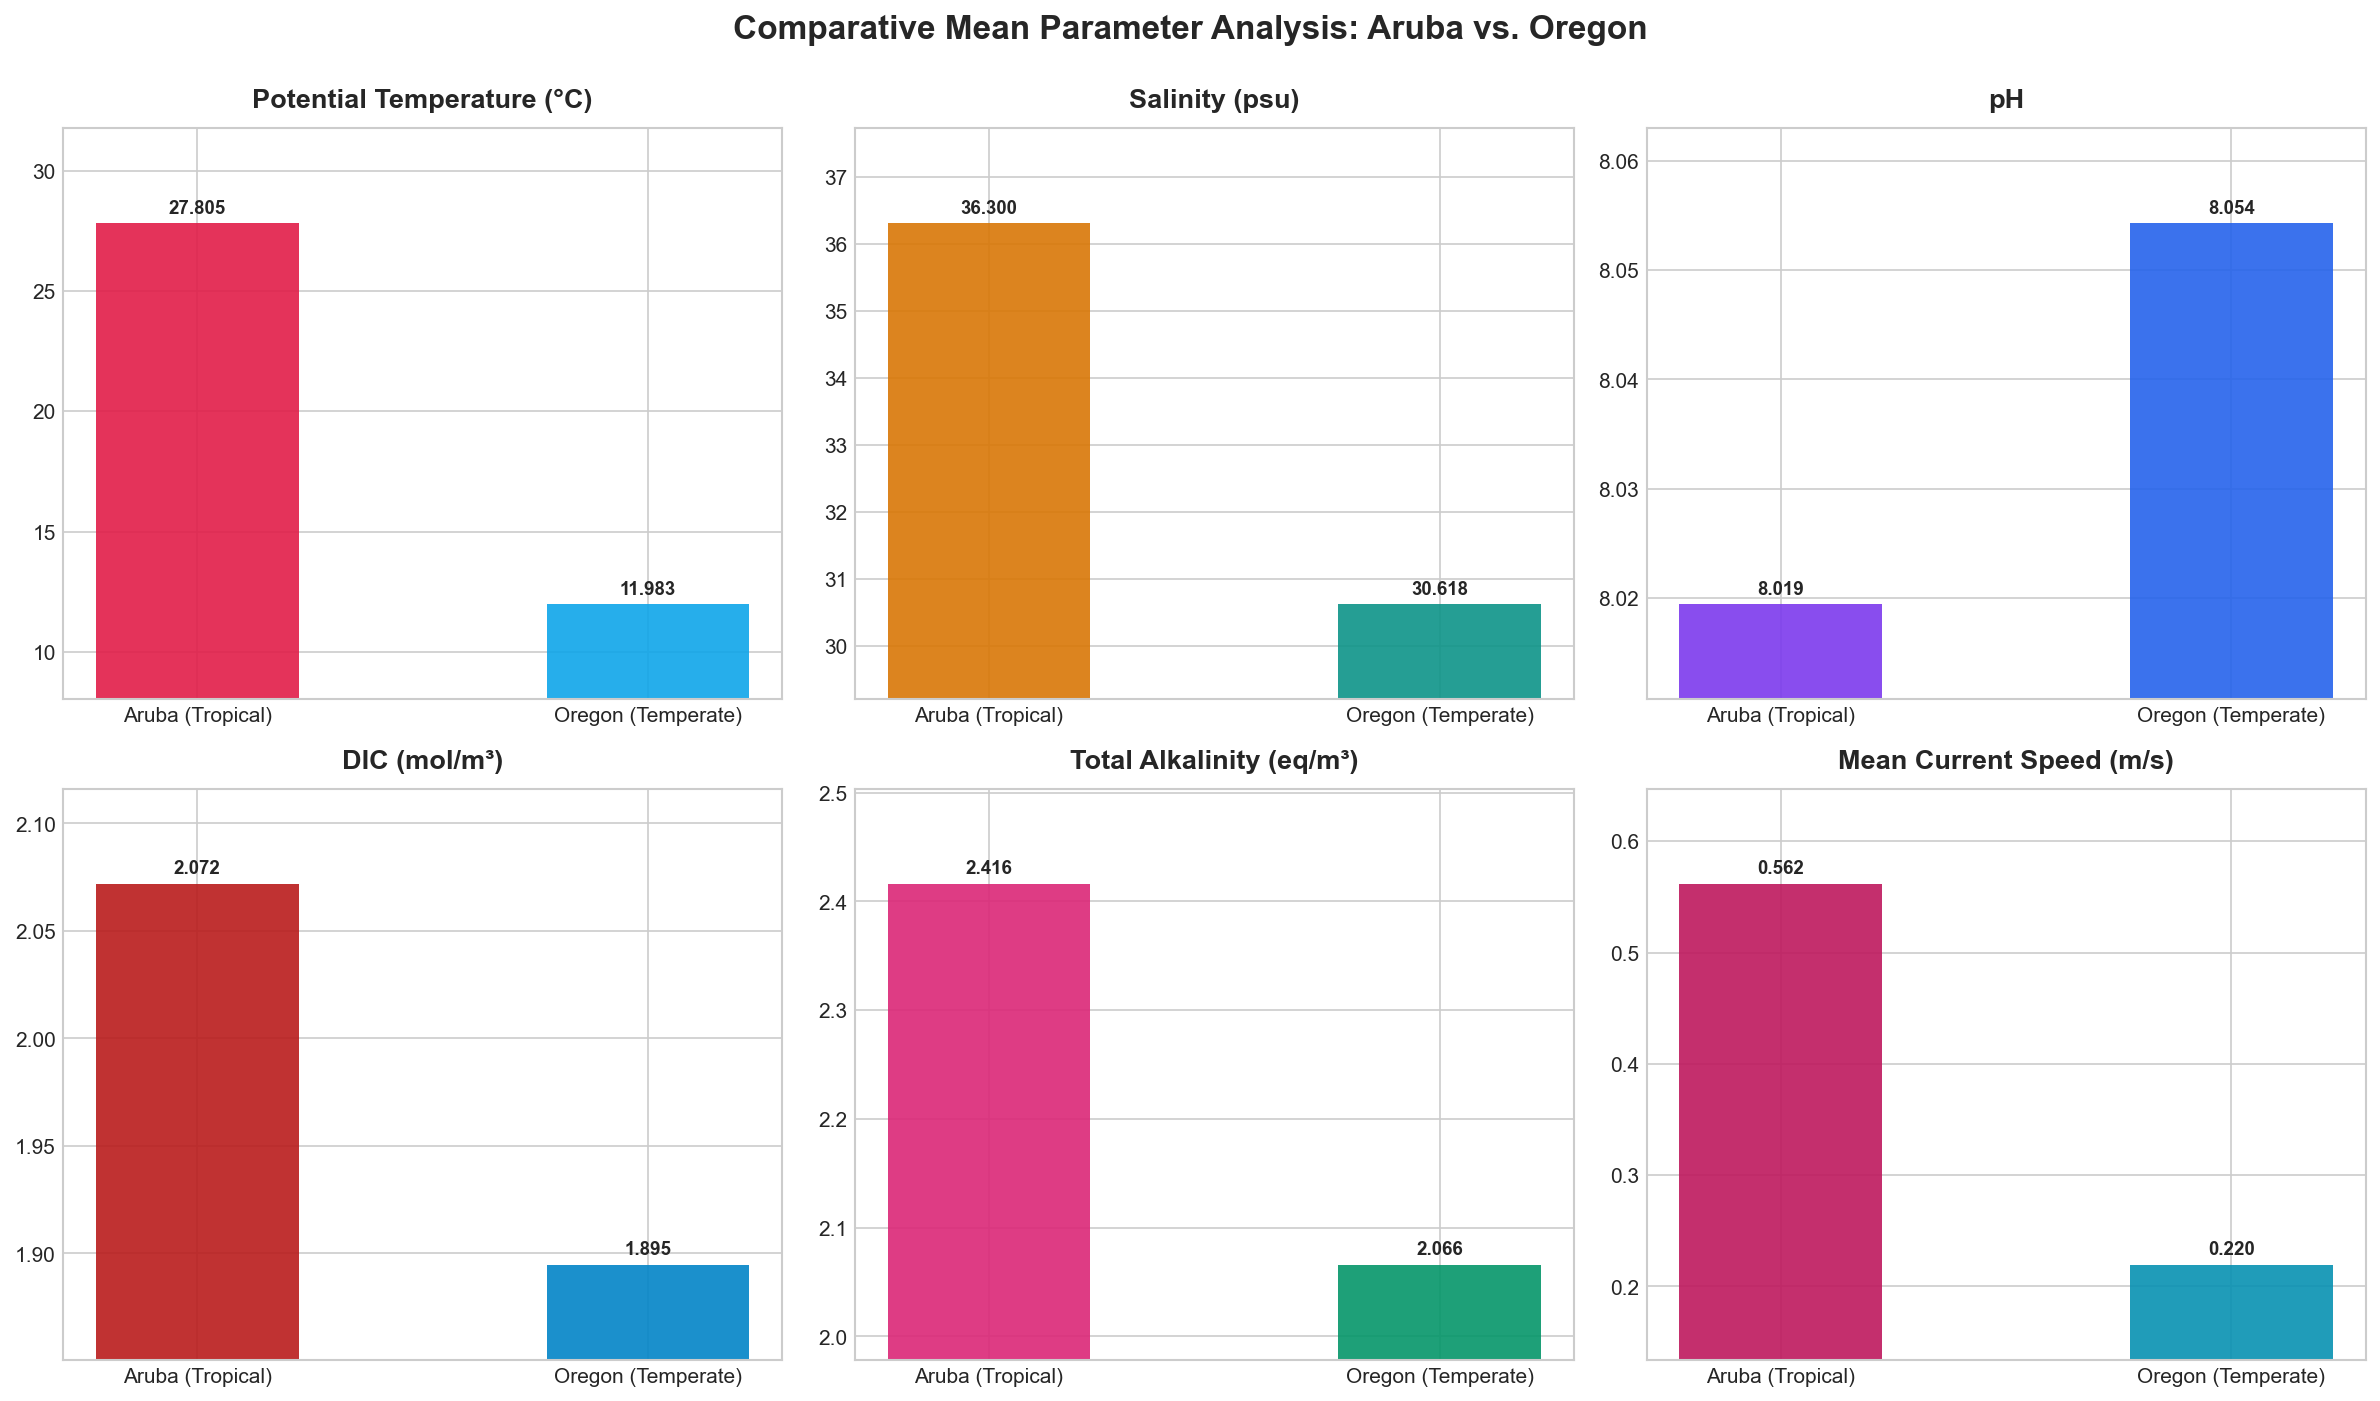

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5), dpi=150)
fig.suptitle('Comparative Mean Parameter Analysis: Aruba vs. Oregon', fontweight='bold', fontsize=16, y=0.98)

vars_to_plot = [
    ('thetao', 'Potential Temperature (°C)', '#e11d48', '#0ea5e9'),
    ('so', 'Salinity (psu)', '#d97706', '#0d9488'),
    ('ph', 'pH', '#7c3aed', '#2563eb'),
    ('dissic', 'DIC (mol/m³)', '#b91c1c', '#0284c7'),
    ('talk', 'Total Alkalinity (eq/m³)', '#db2777', '#059669'),
    ('speed', 'Mean Current Speed (m/s)', '#be185d', '#0891b2')
]

for idx, (var, label, color_a, color_o) in enumerate(vars_to_plot):
    ax = axes[idx // 3, idx % 3]
    vals = [aruba_means[var], oregon_means[var]]
    bars = ax.bar(['Aruba (Tropical)', 'Oregon (Temperate)'], vals, color=[color_a, color_o], width=0.45, edgecolor='none', alpha=0.9)
    ax.set_title(label, fontweight='bold', pad=10)
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    span = max(vals) - min(vals)
    if span == 0:
        ax.set_ylim(0, max(vals) * 1.25)
    else:
        ax.set_ylim(max(0, min(vals) - 0.25*span), max(vals) + 0.25*span)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

### Spatial Averaging over Time
We average out the time dimension (`dim='time'`) to look at the spatial distributions of the variables.

In [6]:
print("Calculating spatial maps by averaging over the time dimension...")
mean_a_phy_spatial = ds_a_phy.mean(dim='time')
mean_o_phy_spatial = ds_o_phy.mean(dim='time')
mean_a_bgc_spatial = ds_a_bgc.mean(dim='time')
mean_o_bgc_spatial = ds_o_bgc.mean(dim='time')
print("Temporal mean grids generated!")

Calculating spatial maps by averaging over the time dimension...
Temporal mean grids generated!


### Figure 2: Mean Seawater Surface Current Fields (Quiver + Speed)
In this visualization, we overlay current velocity vector arrows (from the mean `uo` and `vo` components) onto a contour map of mean current speed.

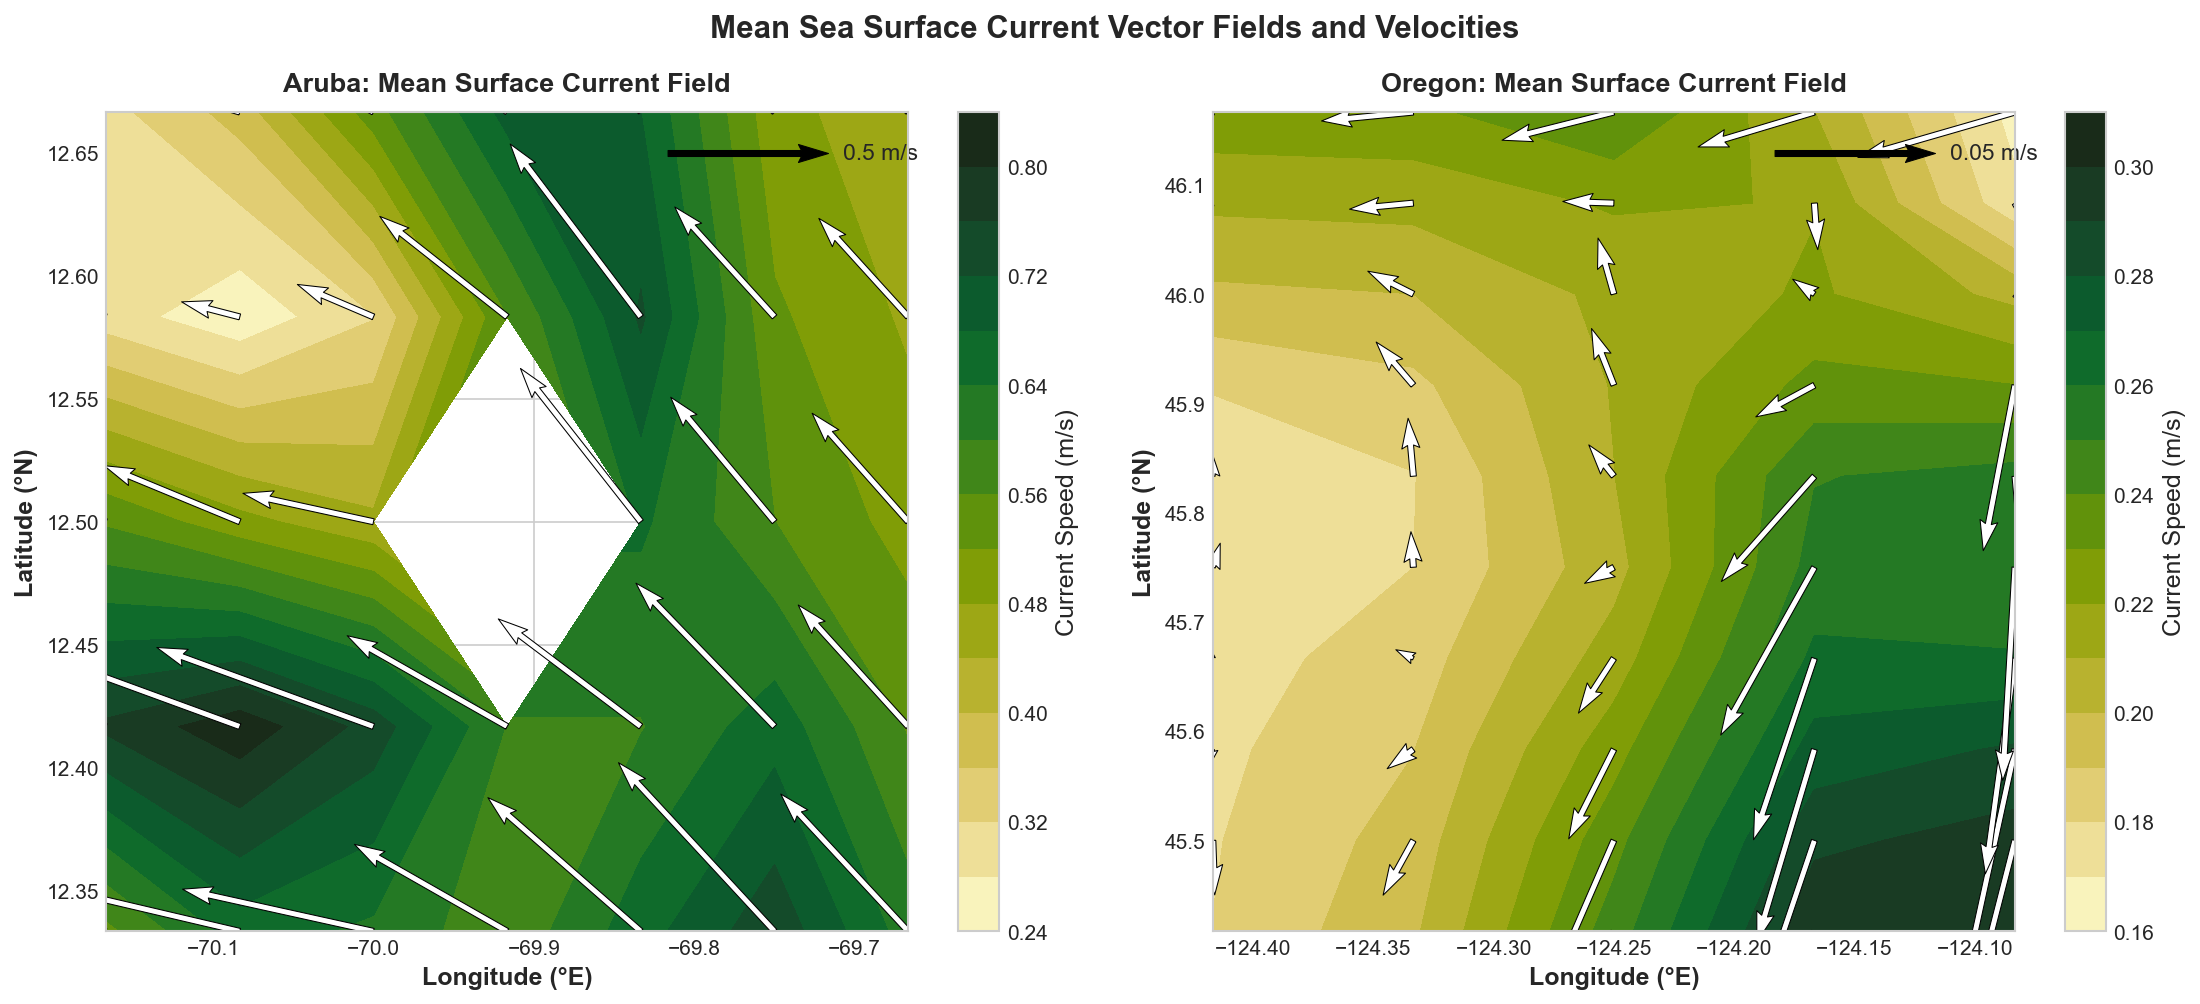

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.8), dpi=150)

# Aruba currents
lon_a = mean_a_phy_spatial['longitude'].values
lat_a = mean_a_phy_spatial['latitude'].values
u_a = mean_a_phy_spatial['uo'].isel(depth=0).values
v_a = mean_a_phy_spatial['vo'].isel(depth=0).values
speed_a = mean_a_phy_spatial['speed'].isel(depth=0).values

im1 = ax1.contourf(lon_a, lat_a, speed_a, cmap=cmocean.cm.speed, levels=15)
q1 = ax1.quiver(lon_a, lat_a, u_a, v_a, color='white', edgecolor='black', linewidth=0.5, scale=2.5)
ax1.quiverkey(q1, 0.9, 0.95, 0.5, "0.5 m/s", labelpos='E', coordinates='axes', color='black')
ax1.set_title('Aruba: Mean Surface Current Field', fontweight='bold', pad=10)
ax1.set_xlabel('Longitude (°E)', fontweight='semibold')
ax1.set_ylabel('Latitude (°N)', fontweight='semibold')
fig.colorbar(im1, ax=ax1, label='Current Speed (m/s)')

# Oregon currents
lon_o = mean_o_phy_spatial['longitude'].values
lat_o = mean_o_phy_spatial['latitude'].values
u_o = mean_o_phy_spatial['uo'].isel(depth=0).values
v_o = mean_o_phy_spatial['vo'].isel(depth=0).values
speed_o = mean_o_phy_spatial['speed'].isel(depth=0).values

im2 = ax2.contourf(lon_o, lat_o, speed_o, cmap=cmocean.cm.speed, levels=15)
q2 = ax2.quiver(lon_o, lat_o, u_o, v_o, color='white', edgecolor='black', linewidth=0.5, scale=0.25)
ax2.quiverkey(q2, 0.9, 0.95, 0.05, "0.05 m/s", labelpos='E', coordinates='axes', color='black')
ax2.set_title('Oregon: Mean Surface Current Field', fontweight='bold', pad=10)
ax2.set_xlabel('Longitude (°E)', fontweight='semibold')
ax2.set_ylabel('Latitude (°N)', fontweight='semibold')
fig.colorbar(im2, ax=ax2, label='Current Speed (m/s)')

plt.suptitle('Mean Sea Surface Current Vector Fields and Velocities', fontweight='bold', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

### Figure 3: Mean Sea Surface Temperature & Salinity Spatial Distribution
These maps show the spatial distribution of mean temperature and salinity for both domains.

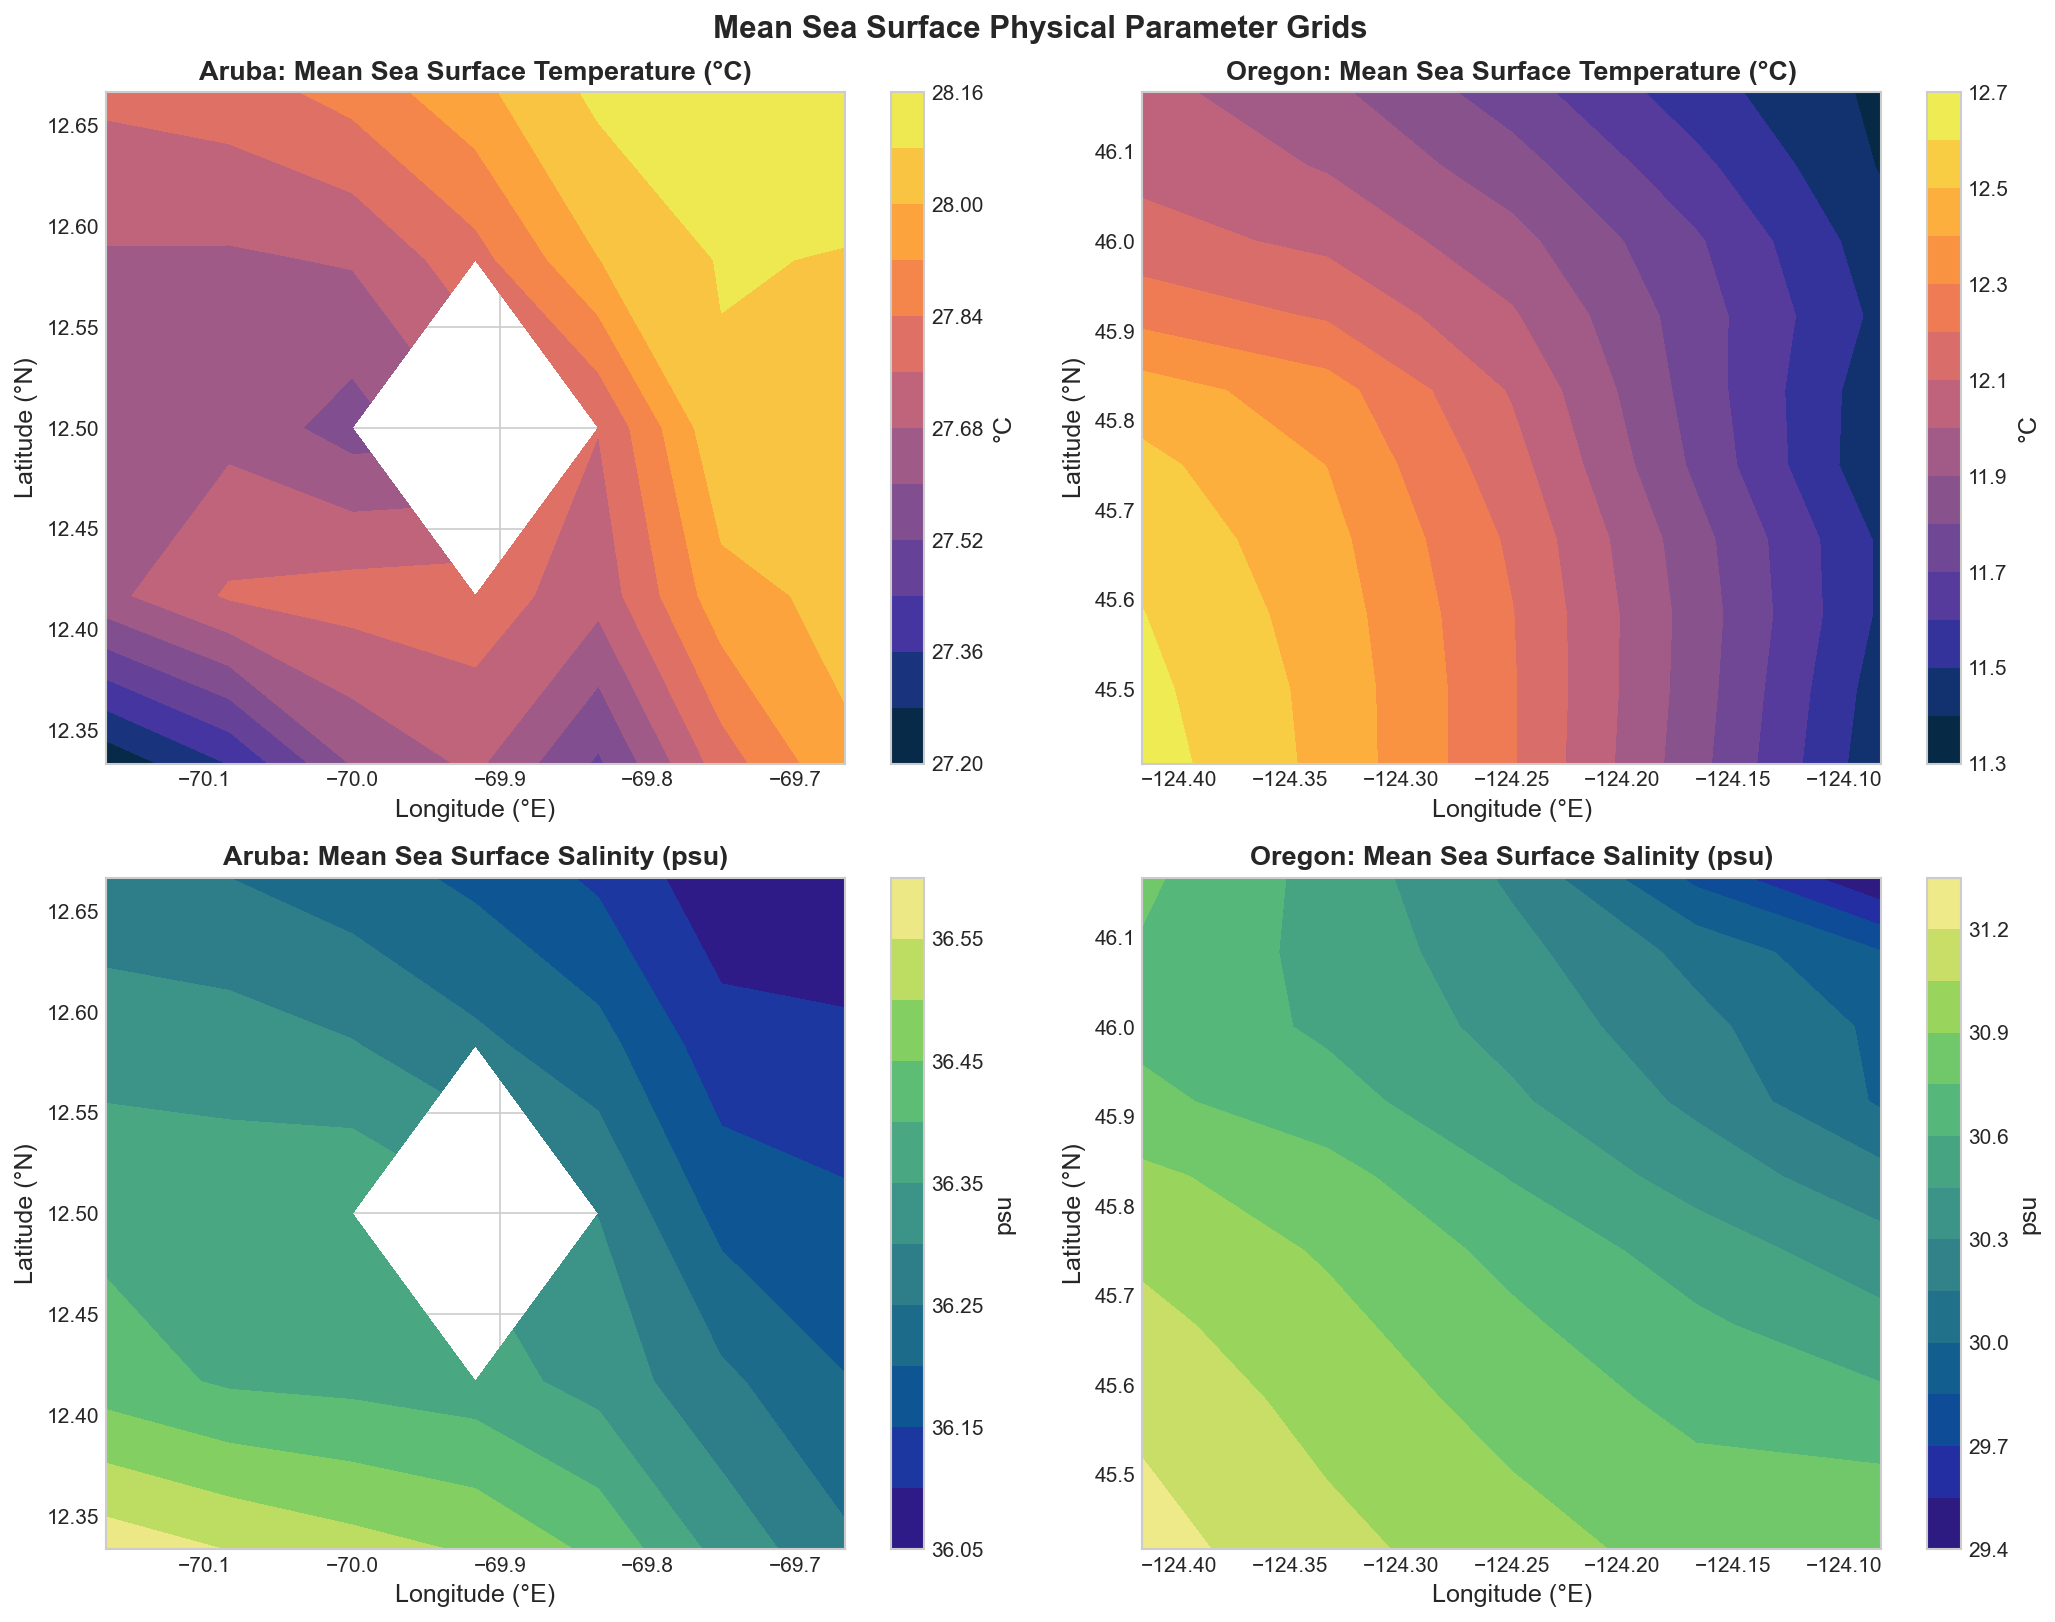

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=150)

# Aruba Temp
im_a_t = axes[0, 0].contourf(lon_a, lat_a, mean_a_phy_spatial['thetao'].isel(depth=0).values, cmap=cmocean.cm.thermal, levels=12)
axes[0, 0].set_title('Aruba: Mean Sea Surface Temperature (°C)', fontweight='bold')
axes[0, 0].set_xlabel('Longitude (°E)')
axes[0, 0].set_ylabel('Latitude (°N)')
fig.colorbar(im_a_t, ax=axes[0, 0], label='°C')

# Oregon Temp
im_o_t = axes[0, 1].contourf(lon_o, lat_o, mean_o_phy_spatial['thetao'].isel(depth=0).values, cmap=cmocean.cm.thermal, levels=12)
axes[0, 1].set_title('Oregon: Mean Sea Surface Temperature (°C)', fontweight='bold')
axes[0, 1].set_xlabel('Longitude (°E)')
axes[0, 1].set_ylabel('Latitude (°N)')
fig.colorbar(im_o_t, ax=axes[0, 1], label='°C')

# Aruba Salinity
im_a_s = axes[1, 0].contourf(lon_a, lat_a, mean_a_phy_spatial['so'].isel(depth=0).values, cmap=cmocean.cm.haline, levels=12)
axes[1, 0].set_title('Aruba: Mean Sea Surface Salinity (psu)', fontweight='bold')
axes[1, 0].set_xlabel('Longitude (°E)')
axes[1, 0].set_ylabel('Latitude (°N)')
fig.colorbar(im_a_s, ax=axes[1, 0], label='psu')

# Oregon Salinity
im_o_s = axes[1, 1].contourf(lon_o, lat_o, mean_o_phy_spatial['so'].isel(depth=0).values, cmap=cmocean.cm.haline, levels=12)
axes[1, 1].set_title('Oregon: Mean Sea Surface Salinity (psu)', fontweight='bold')
axes[1, 1].set_xlabel('Longitude (°E)')
axes[1, 1].set_ylabel('Latitude (°N)')
fig.colorbar(im_o_s, ax=axes[1, 1], label='psu')

plt.suptitle('Mean Sea Surface Physical Parameter Grids', fontweight='bold', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

### Figure 4: Mean Biogeochemical Properties (pH, DIC, Total Alkalinity)
Since the biogeochemical datasets have lower resolution spatial grids (Aruba is 1x2, Oregon is 3x1), standard contour plots are not ideal. Instead, we use flat color grids (square scatter plots) to display the mean spatial values for each cell.

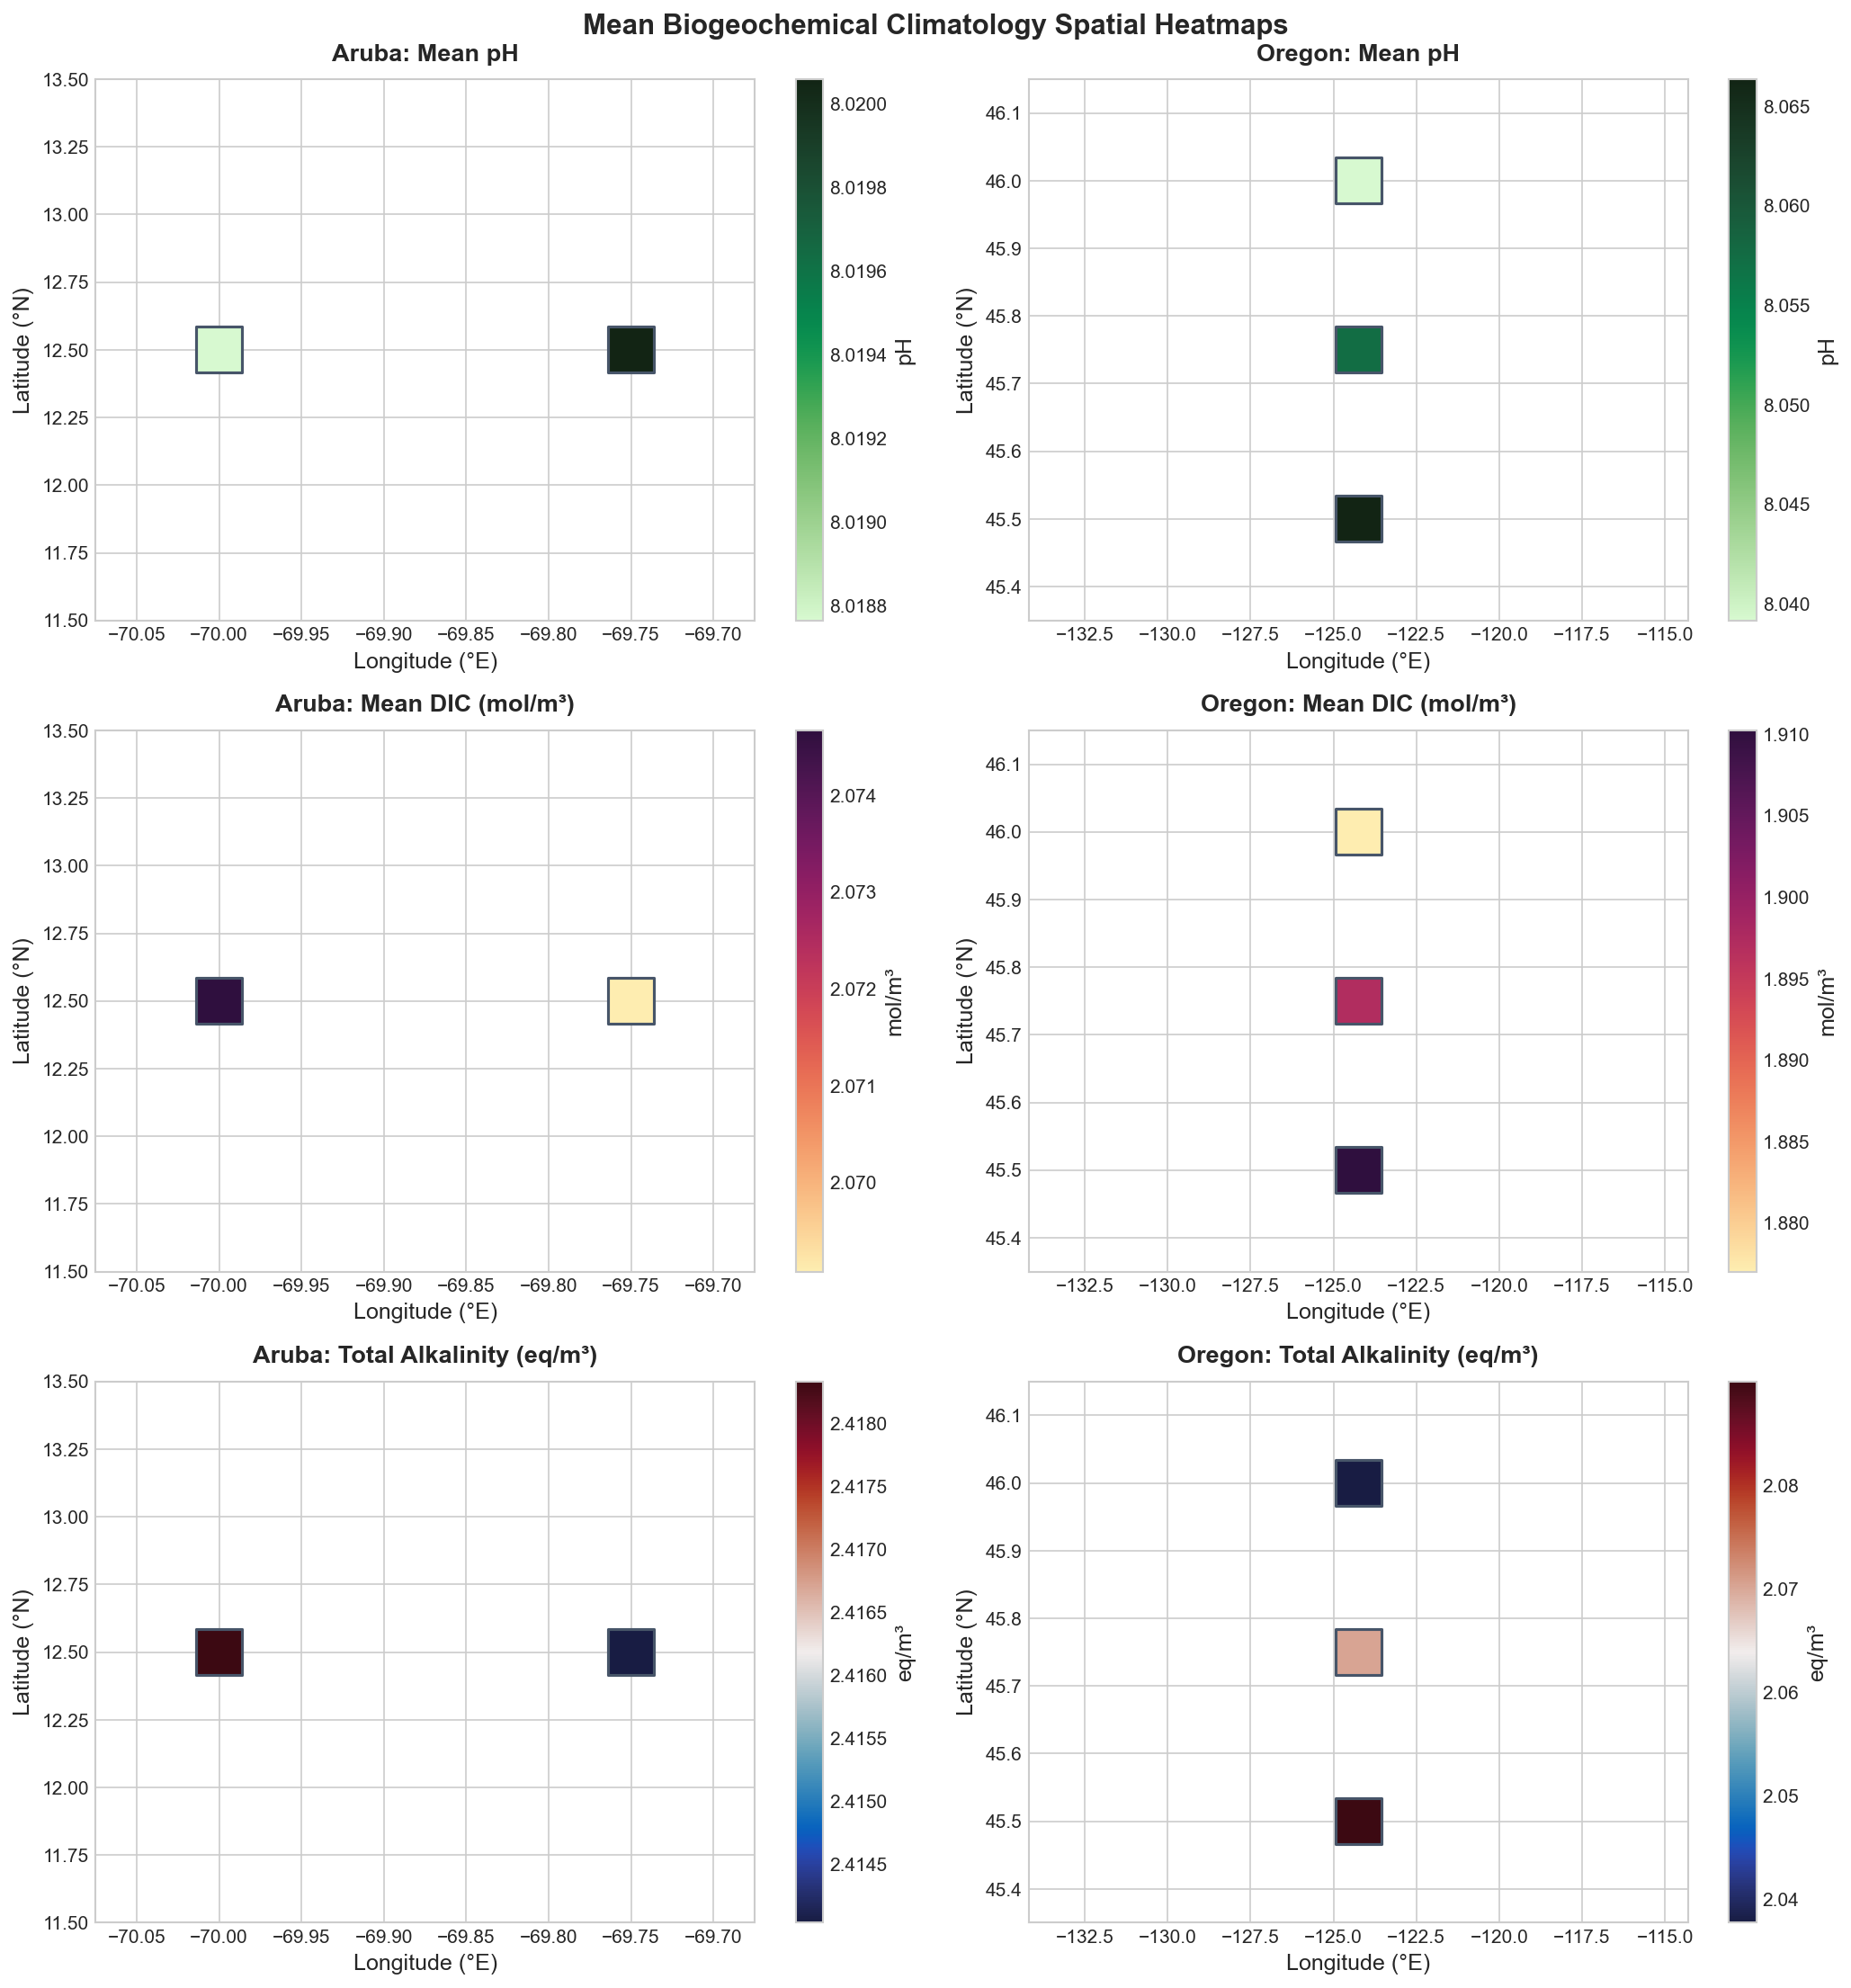

In [9]:
lon_a_bgc = mean_a_bgc_spatial['longitude'].values
lat_a_bgc = mean_a_bgc_spatial['latitude'].values
lon_o_bgc = mean_o_bgc_spatial['longitude'].values
lat_o_bgc = mean_o_bgc_spatial['latitude'].values

fig, axes = plt.subplots(3, 2, figsize=(14, 15), dpi=150)

def plot_bgc_grid(ax, lon, lat, data, title, cmap, label):
    if len(lon) > 1 and len(lat) > 1:
        im = ax.contourf(lon, lat, data, cmap=cmap, levels=10)
    else:
        # Grid has dimension of length 1, use block scatter marker representations
        lon_grid, lat_grid = np.meshgrid(lon, lat)
        im = ax.scatter(lon_grid.flatten(), lat_grid.flatten(), c=data.flatten(), cmap=cmap, s=600, marker='s', edgecolors='#475569', linewidth=1.5)
        # Set grid margins to make dots readable
        ax.margins(0.3)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    fig.colorbar(im, ax=ax, label=label)

# Aruba BGC
plot_bgc_grid(axes[0, 0], lon_a_bgc, lat_a_bgc, mean_a_bgc_spatial['ph'].isel(depth=0).values, 'Aruba: Mean pH', cmocean.cm.algae, 'pH')
plot_bgc_grid(axes[1, 0], lon_a_bgc, lat_a_bgc, mean_a_bgc_spatial['dissic'].isel(depth=0).values, 'Aruba: Mean DIC (mol/m³)', cmocean.cm.matter, 'mol/m³')
plot_bgc_grid(axes[2, 0], lon_a_bgc, lat_a_bgc, mean_a_bgc_spatial['talk'].isel(depth=0).values, 'Aruba: Total Alkalinity (eq/m³)', cmocean.cm.balance, 'eq/m³')

# Oregon BGC
plot_bgc_grid(axes[0, 1], lon_o_bgc, lat_o_bgc, mean_o_bgc_spatial['ph'].isel(depth=0).values, 'Oregon: Mean pH', cmocean.cm.algae, 'pH')
plot_bgc_grid(axes[1, 1], lon_o_bgc, lat_o_bgc, mean_o_bgc_spatial['dissic'].isel(depth=0).values, 'Oregon: Mean DIC (mol/m³)', cmocean.cm.matter, 'mol/m³')
plot_bgc_grid(axes[2, 1], lon_o_bgc, lat_o_bgc, mean_o_bgc_spatial['talk'].isel(depth=0).values, 'Oregon: Total Alkalinity (eq/m³)', cmocean.cm.balance, 'eq/m³')

plt.suptitle('Mean Biogeochemical Climatology Spatial Heatmaps', fontweight='bold', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()